In [15]:
import torch
import torch.nn as nn
from torch import optim
import numpy as np
import random
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
# import necessary classes from Assignment 2

class Indexer(object):
    """
    Bijection between objects and integers starting at 0. Useful for mapping
    labels, features, etc. into coordinates of a vector space.

    Attributes:
        objs_to_ints
        ints_to_objs
    """
    def __init__(self):
        self.objs_to_ints = {}
        self.ints_to_objs = {}

    def __repr__(self):
        return str([str(self.get_object(i)) for i in range(0, len(self))])

    def __str__(self):
        return self.__repr__()

    def __len__(self):
        return len(self.objs_to_ints)

    def get_object(self, index):
        """
        :param index: integer index to look up
        :return: Returns the object corresponding to the particular index or None if not found
        """
        if (index not in self.ints_to_objs):
            return None
        else:
            return self.ints_to_objs[index]

    def contains(self, object):
        """
        :param object: object to look up
        :return: Returns True if it is in the Indexer, False otherwise
        """
        return self.index_of(object) != -1

    def index_of(self, object):
        """
        :param object: object to look up
        :return: Returns -1 if the object isn't present, index otherwise
        """
        if (object not in self.objs_to_ints):
            return -1
        else:
            return self.objs_to_ints[object]

    def add_and_get_index(self, object, add=True):
        """
        Adds the object to the index if it isn't present, always returns a nonnegative index
        :param object: object to look up or add
        :param add: True by default, False if we shouldn't add the object. If False, equivalent to index_of.
        :return: The index of the object
        """
        if not add:
            return self.index_of(object)
        if (object not in self.objs_to_ints):
            new_idx = len(self.objs_to_ints)
            self.objs_to_ints[object] = new_idx
            self.ints_to_objs[new_idx] = object
        return self.objs_to_ints[object]

class WordEmbeddings:
    """
    Wraps an Indexer and a list of 1-D numpy arrays where each position in the list is the vector for the corresponding
    word in the indexer. The 0 vector is returned if an unknown word is queried.
    """
    def __init__(self, word_indexer, vectors):
        self.word_indexer = word_indexer
        self.vectors = vectors

    def get_initialized_embedding_layer(self, frozen=True, padding_idx=None):
        """
        :param frozen: True if you want the embedding layer to stay frozen, false to fine-tune embeddings
        :param padding_idx: Set to a value that you want to be labeled as "padding" in the embedding space
        :return: torch.nn.Embedding layer you can use in your network
        """
        return torch.nn.Embedding.from_pretrained(torch.FloatTensor(self.vectors), freeze=frozen, padding_idx=padding_idx)

    def get_embedding_length(self):
        return len(self.vectors[0])

    def get_embedding(self, word):
        """
        Returns the embedding for a given word
        :param word: The word to look up
        :return: The UNK vector if the word is not in the Indexer or the vector otherwise
        """
        word_idx = self.word_indexer.index_of(word)
        if word_idx != -1:
            return self.vectors[word_idx]
        else:
            return self.vectors[self.word_indexer.index_of("UNK")]

In [4]:
# assignment 2 code

def read_word_embeddings(embeddings_file: str) -> WordEmbeddings:
    """
    Loads the given embeddings (ASCII-formatted) into a WordEmbeddings object. Augments this with an UNK embedding
    that is the 0 vector. Reads in all embeddings with no filtering -- you should only use this for relativized
    word embedding files.
    :param embeddings_file: path to the file containing embeddings
    :return: WordEmbeddings object reflecting the words and their embeddings
    """
    f = open(embeddings_file, encoding="cp1252")
    word_indexer = Indexer()
    vectors = []
    # Make position 0 a PAD token, which can be useful if you
    word_indexer.add_and_get_index("PAD")
    # Make position 1 the UNK token
    word_indexer.add_and_get_index("UNK")
    for line in f:
        if line.strip() != "":
            space_idx = line.find(' ')
            word = line[:space_idx]
            numbers = line[space_idx+1:]
            float_numbers = [float(number_str) for number_str in numbers.split()]
            vector = np.array(float_numbers)
            word_indexer.add_and_get_index(word)
            # Append the PAD and UNK vectors to start. Have to do this weirdly because we need to read the first line
            # of the file to see what the embedding dim is
            if len(vectors) == 0:
                vectors.append(np.zeros(vector.shape[0]))
                vectors.append(np.zeros(vector.shape[0]))
            vectors.append(vector)
    f.close()
    print("Read in " + repr(len(word_indexer)) + " vectors of size " + repr(vectors[0].shape[0]))
    # Turn vectors into a 2-D numpy array
    return WordEmbeddings(word_indexer, np.array(vectors))

In [5]:
class DAN(nn.Module):
    def __init__(self, hidden_layers: int, hidden_size: int, embeddings: WordEmbeddings, output_size: int):
        super(DAN, self).__init__()
        self.embeddings = embeddings # get embeddings, use self.embeddings.get_embeddings instead of layer
        self.input = nn.Sequential(nn.Linear(embeddings.get_embedding_length(), hidden_size), nn.LeakyReLU(negative_slope=0.2)) # init inpuit layer
        for i in range(hidden_layers): # for each hidden layer
            self.input.append(nn.Linear(hidden_size, hidden_size)) # append hidden layer with hidden_size
            self.input.append(nn.LeakyReLU(negative_slope=0.2)) 
            self.input.append(nn.Dropout(0.2))
        self.output = nn.Linear(hidden_size, output_size) # output layer
        self.output_act = nn.Sigmoid() # output activation for binary classificationS

    def forward(self, x: [str]):
        embeddings = []
        for word in x: # for each word in example
            embeddings.append(self.embeddings.get_embedding(word)) # get the embeddings for all words in example
        emb = torch.FloatTensor(np.mean(embeddings, axis=0)) # average embeddings
        seq = self.input(emb)
        out = self.output_act(self.output(seq))
        return out

In [6]:
embed = read_word_embeddings("embeddings/dolma_300_relativised.txt")

Read in 3491 vectors of size 300


Load data

In [7]:
df = pd.read_csv("../resume_data_cleaned.csv")

In [8]:
df.head()

,matched_score,resume_text,job_text,combined_text,num_skills,num_degrees,num_positions,experience_years,age_min,age_max,skill_jaccard,job_position_name,educational_requirements,skills_required,skills,degree_names,positions
0,0.850000,big data analytics working and database wareho...,senior software engineer b.sc in computer scie...,big data analytics working and database wareho...,21,1,1,1.0,NaN,NaN,0.0,senior software engineer,b.sc in computer science & engineering from a ...,NaN,"[""big data"", ""hadoop"", ""hive"", ""python"", ""mapr...","[""b.tech""]","[""big data analyst""]"
1,0.750000,fresher looking to join as a data analyst and ...,machine learning (ml) engineer m.sc in compute...,fresher looking to join as a data analyst and ...,10,2,1,5.0,NaN,NaN,0.0,machine learning (ml) engineer,m.sc in computer science & engineering or in a...,NaN,"[""data analysis"", ""data analytics"", ""business ...","[""b.sc (maths)"", ""m.sc (science) (statistics)""]","[""business analyst""]"
2,0.416667,software development machine learning deep lea...,"executive/ senior executive- trade marketing, ...",software development machine learning deep lea...,14,1,1,3.0,NaN,NaN,0.0,"executive/ senior executive- trade marketing, ...",master of business administration (mba),brand promotion\r\ncampaign management\r\nfiel...,"[""software development"", ""machine learning"", ""...","[""b.tech""]","[""software developer (machine learning enginee..."
3,0.760000,to obtain a position in a fast-paced business ...,business development executive bachelor/honors...,to obtain a position in a fast-paced business ...,36,1,6,3.0,22.0,30.0,0.0,business development executive,bachelor/honors,fast typing skill\r\nieltsinternet browsing & ...,"[""accounts payables"", ""accounts receivables"", ...","[""computer applications specialist certificate...","[""accountant"", ""accounts receivable clerk"", ""m..."
4,0.650000,professional accountant with an outstanding wo...,senior ios engineer bachelor of science (bsc) ...,professional accountant with an outstanding wo...,32,1,5,4.0,NaN,NaN,0.0,senior ios engineer,bachelor of science (bsc) in computer science,ios\r\nios app developer\r\nios application de...,"[""analytical reasoning"", ""compliance testing k...","[""bachelor of business administration""]","[""staff accountant"", ""senior accountant"", ""tax..."


In [9]:
X = np.array(df["combined_text"])
y = np.array(df["matched_score"])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train[0]

'dedicated and focused professional who excels at prioritizing, completing multiple tasks simultaneously and following through to achieve project goals. seeking a role of increased responsibility and authority. project coordination forward-thinking mindset microsoft office proficiency business writing results-oriented self-directed strong interpersonal skills organized and detail-oriented accounting accounting systems aia as400 billings bluebeam bonds budgets business management clerical construction management contracts special events filing imaging insurance jd edwards microsoft office negotiations payroll coding project management property management proposals rfi sap scheduling taxes trade shows graphic design, real estate architectural drafting project accountant assistant to vice president owner assistant project manager project manager project coordinator executive assistant recruitment coordination appointment management selection criteria employee orientation performance evalu

Train model

In [13]:
epochs = 25
lr = 0.001
hidden_size = 75
hidden_layers = 3
batch_size = 64

# define model
dan_model = DAN(hidden_layers, hidden_size, embed, 1) # output is one for regression

In [43]:
loss = nn.MSELoss()
optimizer = optim.Adam(dan_model.parameters(), lr=lr)
num_batches = len(X_train) // batch_size
dan_model.train()
for i in range(epochs): # epoch level
    print(f"Epoch {i+1}") 
    error = 0
    for j in range(num_batches): # batch level
        batch_X = X_train[j*batch_size:(j+1)*batch_size]
        batch_y = y_train[j*batch_size:(j+1)*batch_size]
        e = 0
        for example_X, example_y in zip(batch_X, batch_y): # resume - match score level
            e += loss(dan_model.forward(example_X), torch.FloatTensor([example_y]))
        error += e
        dan_model.zero_grad()
        e.backward()
        optimizer.step()
    print(f"Error for epoch {i+1}: {error:.2f}")

Epoch 1
Error for epoch 1: 226.87
Epoch 2
Error for epoch 2: 216.72
Epoch 3
Error for epoch 3: 214.81
Epoch 4
Error for epoch 4: 213.61
Epoch 5
Error for epoch 5: 211.97
Epoch 6
Error for epoch 6: 211.42
Epoch 7
Error for epoch 7: 208.48
Epoch 8
Error for epoch 8: 208.30
Epoch 9
Error for epoch 9: 206.61
Epoch 10
Error for epoch 10: 205.73
Epoch 11
Error for epoch 11: 204.83
Epoch 12
Error for epoch 12: 204.50
Epoch 13
Error for epoch 13: 204.20
Epoch 14
Error for epoch 14: 203.04
Epoch 15
Error for epoch 15: 203.42
Epoch 16
Error for epoch 16: 202.90
Epoch 17
Error for epoch 17: 202.36
Epoch 18
Error for epoch 18: 202.04
Epoch 19
Error for epoch 19: 201.26
Epoch 20
Error for epoch 20: 200.47
Epoch 21
Error for epoch 21: 200.37
Epoch 22
Error for epoch 22: 201.69
Epoch 23
Error for epoch 23: 200.66
Epoch 24
Error for epoch 24: 199.96
Epoch 25
Error for epoch 25: 199.56


In [44]:
# save model weights
torch.save(dan_model.state_dict(), "models/DAN_Sigmoid_Leaky_final.pth")

In [14]:
# use this cell if you wish to load the model without retraining
dan_model = DAN(hidden_layers, hidden_size, embed, 1)
reload = torch.load("models/DAN_Sigmoid_Leaky_final.pth", weights_only=False)
dan_model.load_state_dict(reload)

<All keys matched successfully>

In [16]:
# load libraries for eval
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [17]:
dan_model.eval()
y_pred = np.zeros(len(X_test))
with torch.no_grad():
    for i in range(len(X_test)):
        y_pred[i] = dan_model(X_test[i])

In [18]:
print(y_pred)

[0.66597831 0.65672237 0.44165245 ... 0.62072659 0.66217709 0.6830411 ]


In [19]:
mse_dan = mean_squared_error(y_test, y_pred)
r2_dan = r2_score(y_test, y_pred)
mae_dan = mean_absolute_error(y_test, y_pred)

print("DAN Experiment w/ no numerical features")
print(f"MSE: {mse_dan:.4f}")
print(f"R2:  {r2_dan:.4f}")
print(f"MAE:  {mae_dan:.4f}")

DAN Experiment w/ no numerical features
MSE: 0.0255
R2:  0.0778
MAE:  0.1261


In [23]:
import matplotlib.pyplot as plt

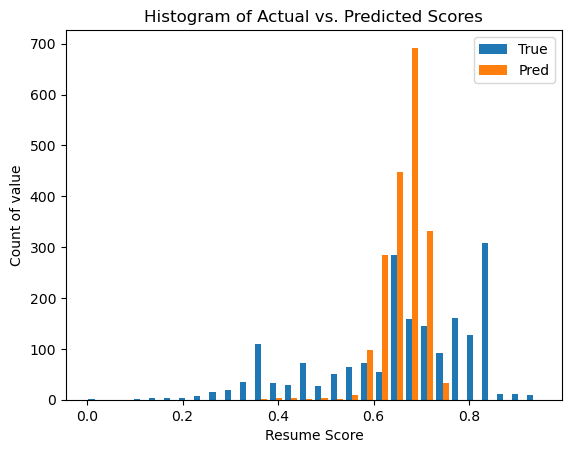

In [49]:
plt.hist([y_test, y_pred], bins=30, label=['True', 'Pred'])
plt.legend(loc='upper right')
plt.xlabel("Resume Score")
plt.ylabel("Count of value")
plt.title("Histogram of Actual vs. Predicted Scores")
plt.show()

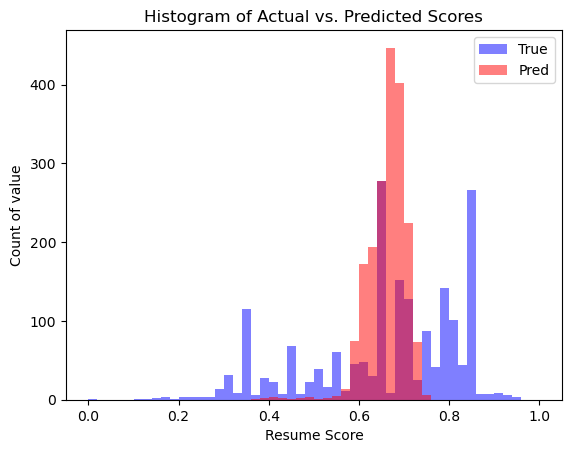

In [50]:
plt.hist(y_test, bins=50, alpha=0.5, label='True', color='blue', range=(0,1))
plt.hist(y_pred, bins=50, alpha=0.5, label='Pred', color='red', range=(0,1))
plt.legend()
plt.xlabel("Resume Score")
plt.ylabel("Count of value")
plt.title("Histogram of Actual vs. Predicted Scores")
plt.show()

Add numerical values to embeddings

In [26]:
from sklearn.preprocessing import MinMaxScaler

In [37]:
class DAN_Extra(nn.Module):
    def __init__(self, hidden_layers: int, hidden_size: int, extra_cols: int, embeddings: WordEmbeddings, output_size: int):
        super(DAN_Extra, self).__init__()
        self.embeddings = embeddings # get embeddings, use self.embeddings.get_embeddings instead of layer
        self.input = nn.Sequential(nn.Linear(embeddings.get_embedding_length()+extra_cols, hidden_size), nn.LeakyReLU(negative_slope=0.2)) # init inpuit layer
        for i in range(hidden_layers): # for each hidden layer
            self.input.append(nn.Linear(hidden_size, hidden_size)) # append hidden layer with hidden_size
            self.input.append(nn.LeakyReLU(negative_slope=0.2)) 
            self.input.append(nn.Dropout(0.2))
        self.output = nn.Linear(hidden_size, output_size) # output layer
        self.output_act = nn.Sigmoid() # output activation for binary classificationS

    def forward(self, x):
        embeddings = []
        words = str(x["combined_text"]).split()
        for word in words: # for each word in example
            embeddings.append(self.embeddings.get_embedding(word)) # get the embeddings for all words in example
        input_ = np.append(np.mean(embeddings, axis=0), np.float64(x[cols].values)) # average embeddings
        emb = torch.FloatTensor(input_)
        seq = self.input(emb)
        fx = self.output(seq)
        out = self.output_act(fx)
        return out

In [28]:
cols = ["num_skills", "num_degrees", "experience_years", "skill_jaccard"]
numerical = df[cols]

In [29]:
scaler = MinMaxScaler()
numerical_scale = scaler.fit_transform(numerical)
print(numerical_scale)

[[0.14583333 0.09090909 0.         0.        ]
 [0.06944444 0.18181818 0.28571429 0.        ]
 [0.09722222 0.09090909 0.14285714 0.        ]
 ...
 [0.06944444 0.09090909 0.14285714 0.        ]
 [0.08333333 0.09090909 0.28571429 0.        ]
 [0.13888889 0.09090909 0.28571429 0.14102564]]


In [30]:
df[cols] = numerical_scale

In [31]:
X_new = df[["combined_text"] + cols]

In [32]:
X_new.head()

,combined_text,num_skills,num_degrees,experience_years,skill_jaccard
0,big data analytics working and database wareho...,0.145833,0.090909,0.000000,0.0
1,fresher looking to join as a data analyst and ...,0.069444,0.181818,0.285714,0.0
2,software development machine learning deep lea...,0.097222,0.090909,0.142857,0.0
3,to obtain a position in a fast-paced business ...,0.250000,0.090909,0.142857,0.0
4,professional accountant with an outstanding wo...,0.222222,0.090909,0.214286,0.0


In [33]:
X_train_extra, X_test_extra, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

In [34]:
X_train_extra.iloc[0]["combined_text"]

'dedicated and focused professional who excels at prioritizing, completing multiple tasks simultaneously and following through to achieve project goals. seeking a role of increased responsibility and authority. project coordination forward-thinking mindset microsoft office proficiency business writing results-oriented self-directed strong interpersonal skills organized and detail-oriented accounting accounting systems aia as400 billings bluebeam bonds budgets business management clerical construction management contracts special events filing imaging insurance jd edwards microsoft office negotiations payroll coding project management property management proposals rfi sap scheduling taxes trade shows graphic design, real estate architectural drafting project accountant assistant to vice president owner assistant project manager project manager project coordinator executive assistant recruitment coordination appointment management selection criteria employee orientation performance evalu

In [38]:
epochs = 5
lr = 0.005
hidden_size = 50
hidden_layers = 2
batch_size = 32

# define model
dan_model_extra = DAN_Extra(hidden_layers, hidden_size, len(cols), embed, 1) # output is one for regression
dan_model_extra

DAN_Extra(
  (input): Sequential(
    (0): Linear(in_features=304, out_features=50, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=50, out_features=50, bias=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=50, out_features=1, bias=True)
  (output_act): Sigmoid()
)

In [39]:
loss = nn.MSELoss()
optimizer = optim.Adam(dan_model_extra.parameters(), lr=lr)
num_batches = len(X_train_extra) // batch_size
dan_model_extra.train()
for i in range(epochs): # epoch level
    print(f"Epoch {i+1}") 
    error = 0
    for j in range(num_batches): # batch level
        batch_X = X_train_extra.iloc[j*batch_size:(j+1)*batch_size].reset_index().drop(columns=["index"])
        batch_y = y_train[j*batch_size:(j+1)*batch_size]
        e = 0
        for k in range(batch_size):
            example_x = batch_X.iloc[k]
            example_y = batch_y[k]
            output = dan_model_extra(example_x)
            e += loss(output, torch.FloatTensor([example_y]))
        error += e.item()
        dan_model_extra.zero_grad()
        e.backward()
        optimizer.step()
    print(f"Error for epoch {i+1}: {error:.2f}")

Epoch 1
Error for epoch 1: nan
Epoch 2
Error for epoch 2: nan
Epoch 3
Error for epoch 3: nan
Epoch 4
Error for epoch 4: nan
Epoch 5
Error for epoch 5: nan


Adding structured variables led to nan values after about 10 training loops. It did not appear to act like an exploding gradient because the values would be stable then randomly become all nan